# Toy Example (Adult Dataset)

In [1]:
from data.data_preprocess import DataProcessor
from model.tabcascade import TabCascade
from omegaconf import OmegaConf
from evaluation.eval_detection import DetectionScore
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# select dataset
DATASET = "adult"
SEED = 0

# pre-processes the training data
# for numerical features: quantile transform and standardize
# for categorical features: ordinal encoding
# in our case: also simulate missings using MNAR mechanism
data_processor = DataProcessor(
    DATASET,
    None,
    SEED,
    val_prop=0.1,
    test_prop=0.2,
    cat_min_freq=5,
    missing_mechanism="mnar",
    seed_missings=SEED,
    p_miss=0.1,
    p_obs=0.3,
)

# retrieve data for training
train_loader, _ = data_processor.get_data_loaders(mean_impute=False)
x_cat_trn = train_loader.data[0]
x_num_trn = train_loader.data[1]

# remove missingness indicator (used for other models, which do not explicitly model missings) from cat features
x_cat_trn = x_cat_trn[:, : len(data_processor.cat_cols)]

= Processing adult with seed 0 =
Rows with missings in target removed: 0
Cat cols: 9
Num cols: 6
Simulating MNAR...


In [3]:
# setup model
config = OmegaConf.load("model/config.yaml")
tabcascade = TabCascade(config, SEED)

In [4]:
# train model
tabcascade.train(x_cat_trn, x_num_trn)

Total parameters = 3003825
Lowres parameters = 1996889
Highres parameters = 1006936


100%|██████████| 30000/30000 [23:09<00:00, 21.59it/s, loss (lowres)=1.2324, loss (highres)=0.0010]


In [5]:
# save model if required
save_path = Path.cwd() / "checkpoint"
tabcascade.save_model(save_path)


In [ ]:
# uncomment to load model if required
# save_path = Path.cwd() / "checkpoint"
# tabcascade.load_model(save_path)

In [6]:
# generate data (as many samples as in training set)
n_samples = x_num_trn.shape[0]
x_cat_gen, x_num_gen = tabcascade.sample(n_samples)

In [7]:
# post-process data to invert pre-processsing applied to training data
df_gen = data_processor.postprocess(x_cat_gen, x_num_gen, includes_miss_ind=False)
df_gen

income,workclass,education,marital-status,occupation,relationship,race,gender,native-country,fnlwgt,capital-gain,capital-loss,age,educational-num,hours-per-week
str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64
"""<=50K""","""Private""","""Some-college""","""Never-married""","""Handlers-cleaners""","""Not-in-family""","""White""","""Male""","""United-States""",304783.0,null,0.0,22.0,10.0,null
""">50K""","""Private""","""Masters""","""Married-civ-spouse""","""Exec-managerial""","""Husband""","""White""","""Male""","""United-States""",144981.0,0.0,0.0,59.0,14.0,55.0
"""<=50K""","""Self-emp-not-inc""","""HS-grad""","""Married-civ-spouse""","""Transport-moving""","""Husband""","""White""","""Male""","""United-States""",170457.0,0.0,0.0,75.0,9.0,55.0
""">50K""","""Private""","""HS-grad""","""Married-civ-spouse""","""Craft-repair""","""Husband""","""White""","""Male""","""United-States""",125891.0,0.0,null,47.0,9.0,40.0
"""<=50K""","""Private""","""HS-grad""","""Married-civ-spouse""","""Adm-clerical""","""Husband""","""White""","""Male""","""United-States""",121256.0,null,0.0,29.0,9.0,40.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""<=50K""","""Private""","""Bachelors""","""Married-civ-spouse""","""Prof-specialty""","""Husband""","""Other""","""Male""","""China""",null,0.0,0.0,null,null,40.0
"""<=50K""","""Private""","""Assoc-acdm""","""Never-married""","""Sales""","""Not-in-family""","""White""","""Male""","""United-States""",198717.0,0.0,0.0,24.0,12.0,20.0
"""<=50K""","""Private""","""Masters""","""Never-married""","""Exec-managerial""","""Not-in-family""","""White""","""Female""","""United-States""",203543.0,0.0,null,56.0,14.0,40.0


In [8]:
# evaluate via detection score
df_trn, _, _ = data_processor.get_data_splits()
detect_score = DetectionScore(data_processor.cat_cols, data_processor.num_cols)
results = detect_score.estimate_score(df_trn, df_gen, seed=SEED, nfold=5)
print(f'Average detection score over folds (1 is best) = {results["detection_score"]:.4f}')


Average detection score over folds (1 is best) = 0.9193


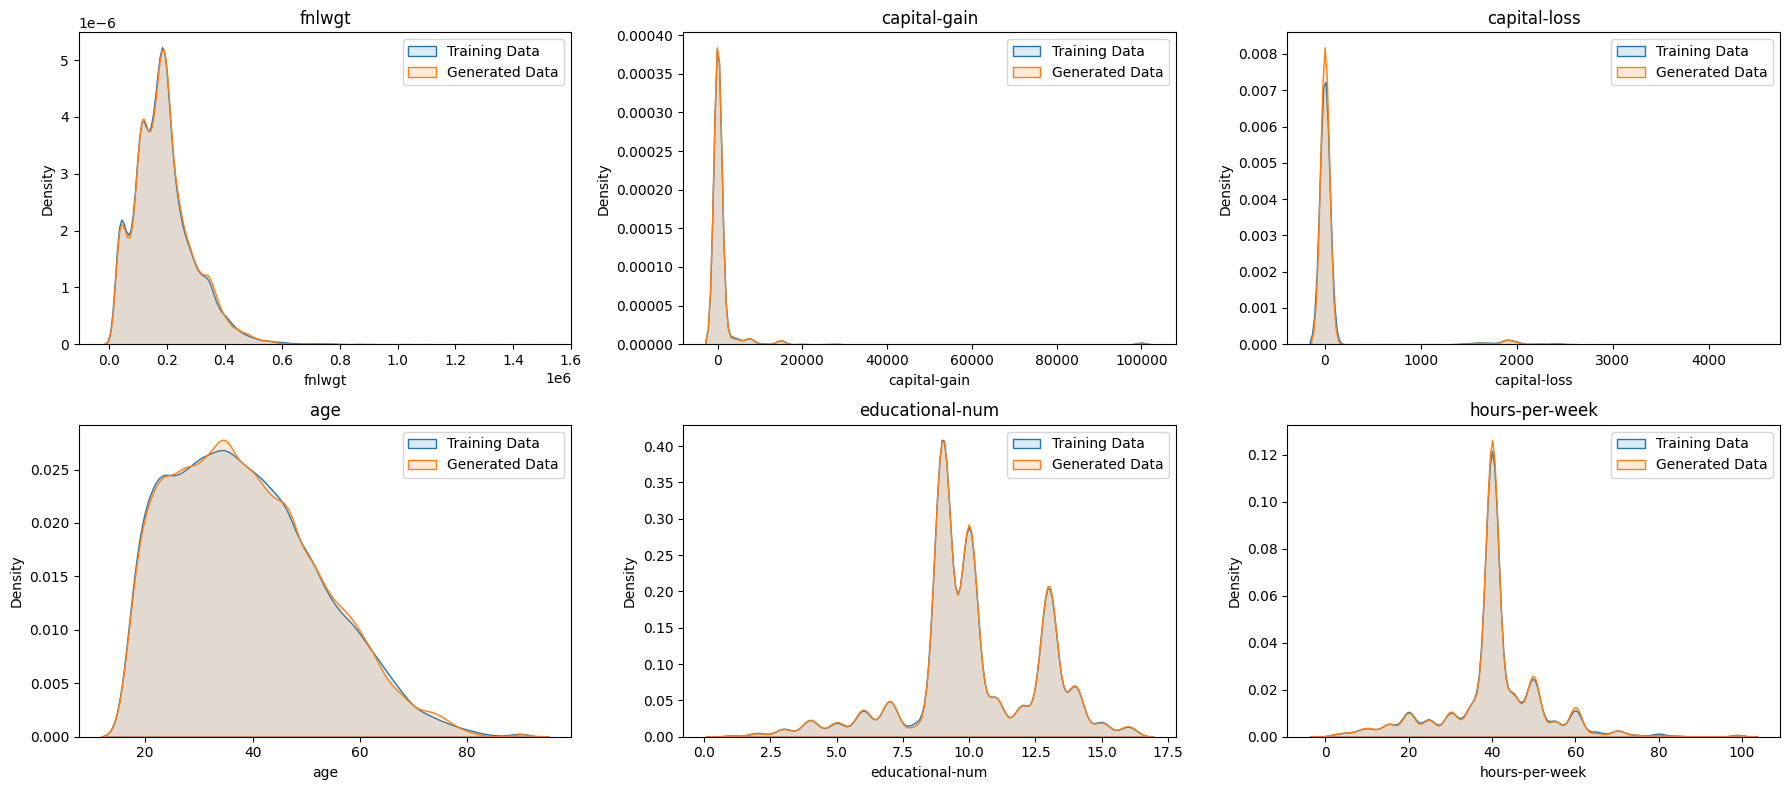

In [9]:
# plot univariate densities for numerical features
def plot_num_densities(num_cols):
    fig, ax = plt.subplots(nrows=2, ncols=len(num_cols) // 2, figsize=(6 * 3, 4 * 2))
    ax = ax.flatten()
    for i, col in enumerate(num_cols):
        sns.kdeplot(df_trn[col], label="Training Data", fill=True, alpha=0.15, ax=ax[i])
        sns.kdeplot(df_gen[col], label="Generated Data", fill=True, alpha=0.15, ax=ax[i])
        ax[i].set_title(col)
        ax[i].set_xlabel(col)
        ax[i].set_ylabel("Density")
        ax[i].legend()
    plt.tight_layout()
    plt.show()

plot_num_densities(data_processor.num_cols)


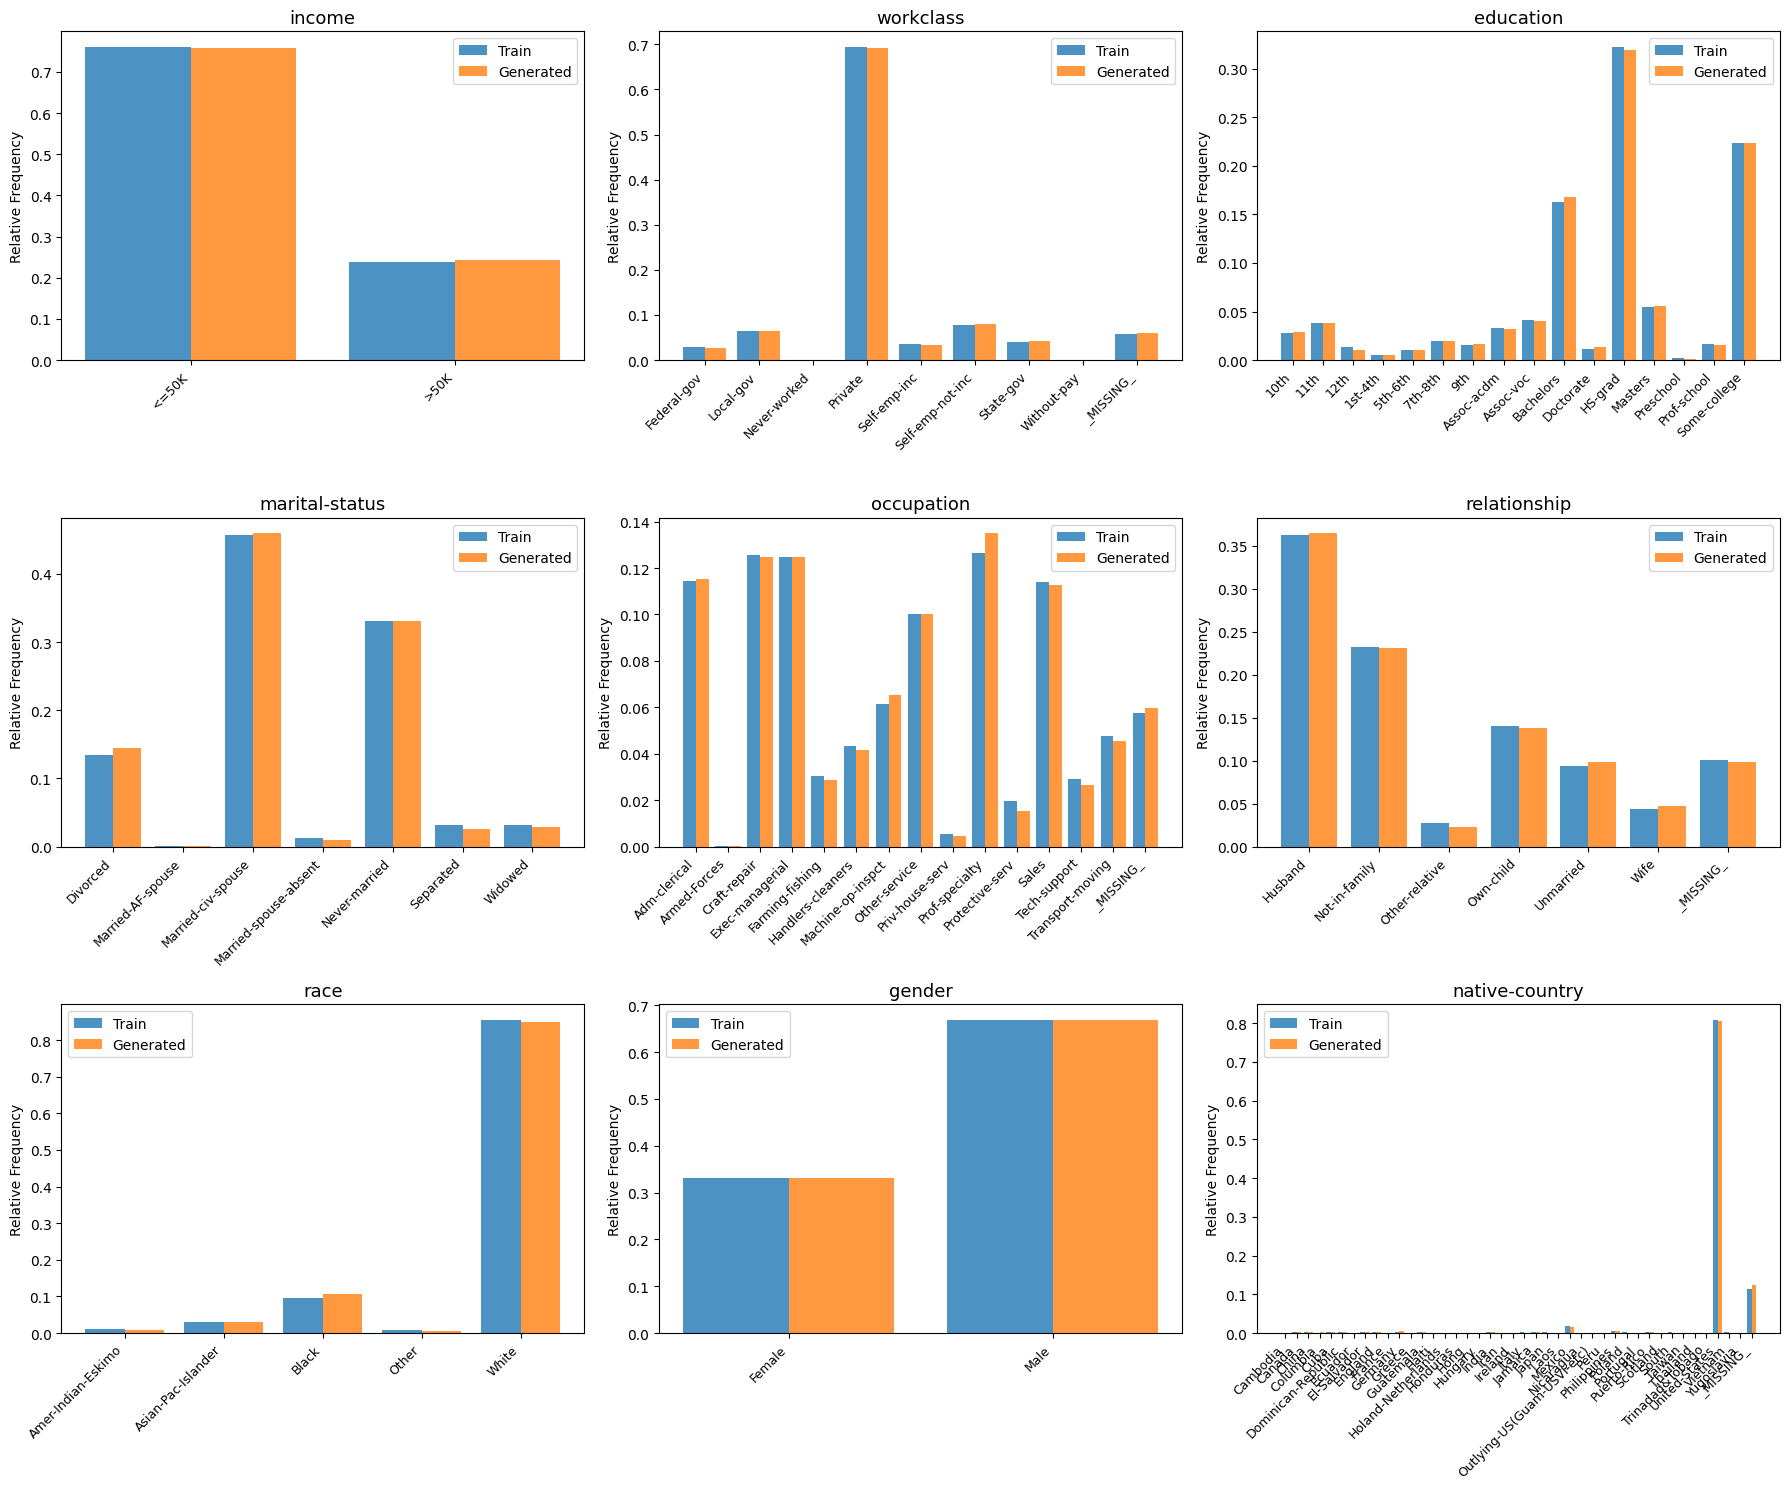

In [10]:
# plot univariate densities for categorical features
def plot_categorical_comparison(df_trn, df_gen, cat_cols):
    n_cols = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        ax = axes[i]

        # Count occurrences and align categories
        trn_counts = df_trn[col].to_pandas().value_counts(normalize=True).sort_index()
        gen_counts = df_gen[col].to_pandas().value_counts(normalize=True).sort_index()

        # Union of all categories from both dataframes
        all_categories = sorted(set(trn_counts.index) | set(gen_counts.index))
        trn_counts = trn_counts.reindex(all_categories, fill_value=0)
        gen_counts = gen_counts.reindex(all_categories, fill_value=0)

        # Plot side-by-side bars
        x = np.arange(len(all_categories))
        width = 0.4
        ax.bar(x - width / 2, trn_counts.values, width, label="Train", alpha=0.8, color="tab:blue")
        ax.bar(x + width / 2, gen_counts.values, width, label="Generated", alpha=0.8, color="tab:orange")

        ax.set_title(col, fontsize=13)
        ax.set_xticks(x)
        ax.set_xticklabels(all_categories, rotation=45, ha="right", fontsize=9)
        ax.set_ylabel("Relative Frequency")
        ax.legend()

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_categorical_comparison(df_trn, df_gen, data_processor.cat_cols)